**Description Of the features of the dataset:**

Y – Latitude coordinate of the observation station.
X – Longitude coordinate of the observation station.
data_payload_id – Unique identifier for the data record.
instance_datetime – Timestamp when the data was recorded.
url – URL reference to the data source.
agency – Organization responsible for the data.
platform_type – Type of platform (e.g., station, balloon, etc.).
platform_id – Numeric ID for the platform.
platform_name – Name of the observation platform or station.
gaw_id – Global Atmosphere Watch ID of the platform.
instrument_name – Name of the instrument used for measurement.
instrument_model – Model of the instrument.
instrument_number – Instrument's identification number.
monthly_date – Date associated with monthly aggregated data.
monthly_columno3 – Monthly average ozone column value.
monthly_stddevo3 – Standard deviation of the monthly ozone values.
monthly_npts – Number of observations used in monthly average.
daily_date – Date of the daily observation.
daily_wlcode – Wavelength code used during observation.
daily_obscode – Observation code (e.g., method or technique).
daily_columno3 – Daily ozone column measurement (Dobson Units).
daily_stddevo3 – Standard deviation of the daily ozone value.
daily_utc_begin – UTC time when observation began.
daily_utc_end – UTC time when observation ended.
daily_utc_mean – Mean UTC time of observation.
daily_nobs – Number of observations for that day.
daily_mmu – Measurement uncertainty for daily ozone.
daily_columnso2 – Daily SO₂ (sulfur dioxide) column measurement.
latest_observation – Flag indicating if this is the most recent data (0 or 1).
country – Country of the observation station.
scientific_authority – Name of the responsible scientist or authority.
version – Version number of the data record.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler


**GPU Based Models**

In [2]:
df=pd.read_csv('New Dataset/result _2.csv')
df.head()


/tmp/ipykernel_719/334508303.py:1: DtypeWarning: Columns (19,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('New Dataset/result _2.csv')


,Y,X,data_payload_id,instance_datetime,url,agency,platform_type,platform_id,platform_name,gaw_id,...,daily_utc_begin,daily_utc_end,daily_utc_mean,daily_nobs,daily_mmu,daily_columnso2,latest_observation,country,scientific_authority,version
0,43.781,-79.468,2260788,2023/12/01 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,MSC,STN,65,Toronto,TOT,...,15.6,19.3,17.4,22.0,2.7,-6.7,0,CAN,Vitali Fioletov,4.15
1,43.781,-79.468,2260768,2023/12/01 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,MSC,STN,65,Toronto,TOT,...,15.1,19.6,17.2,21.0,2.8,-4.9,0,CAN,Vitali Fioletov,4.15
2,43.781,-79.468,2260775,2023/12/01 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,MSC,STN,65,Toronto,TOT,...,15.0,18.9,17.7,15.0,2.7,-3.3,0,CAN,Vitali Fioletov,4.15
3,43.781,-79.468,2260778,2023/12/01 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,MSC,STN,65,Toronto,TOT,...,17.5,19.5,18.5,11.0,2.9,0.9,0,CAN,Vitali Fioletov,4.15
4,58.739,-94.074,2260790,2023/12/01 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,MSC,STN,77,Churchill,CHL,...,13.9,13.9,13.9,1.0,1.7,-3.5,0,CAN,Vitali Fioletov,4.16


In [3]:
df=df.drop(['Y', 'X', 'data_payload_id', 'instance_datetime', 'url', 'agency',
       'platform_type', 'platform_id', 'platform_name', 'gaw_id',
       'instrument_name', 'instrument_model', 'instrument_number',
       'monthly_date', 'monthly_stddevo3', 'monthly_npts','daily_stddevo3',
        'daily_wlcode', 'daily_obscode', 'monthly_columno3',
        'daily_utc_begin', 'daily_utc_end', 'daily_utc_mean',
       'daily_nobs', 'daily_mmu', 'daily_columnso2', 'latest_observation',
       'country', 'scientific_authority', 'version'], axis = 1)
df = df.sort_values('daily_date', ascending=True).reset_index(drop=True)
df = df.groupby('daily_date').mean(numeric_only=True).reset_index()


df.head()

,daily_date,daily_columno3
0,1957-07-01,350.750000
1,1957-07-02,329.300000
2,1957-07-03,322.500000
3,1957-07-04,322.500000
4,1957-07-05,317.966667


In [4]:
df.shape

(24037, 2)

In [5]:
# df['daily_date'] = pd.to_datetime(df['daily_date'], format='%d-%m-%y')

# 2. Sort the dataframe by the full date (oldest to latest)

df = df.sort_values('daily_date', ascending=True).reset_index(drop=True)

# Rolling average feature (7-day)
df['rolling_avg'] = df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
df['rolling_std'] = df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
df['ewm_avg'] = df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
df['ewm_std'] = df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 151):
  df[f'lag{i}'] = df['daily_columno3'].shift(i)

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
print(df.shape)
df.head()

/tmp/ipykernel_719/113173563.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'lag{i}'] = df['daily_columno3'].shift(i)
/tmp/ipykernel_719/113173563.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'lag{i}'] = df['daily_columno3'].shift(i)
/tmp/ipykernel_719/113173563.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented fr

(23887, 156)


,daily_date,daily_columno3,rolling_avg,rolling_std,ewm_avg,ewm_std,lag1,lag2,lag3,lag4,...,lag141,lag142,lag143,lag144,lag145,lag146,lag147,lag148,lag149,lag150
150,1957-11-30,349.80,292.390,31.160327,286.262010,28.091309,294.75,268.45,237.70,297.20,...,336.150,323.450,325.733333,339.800000,327.066667,317.966667,322.500000,322.500000,329.300000,350.750000
151,1957-12-01,311.25,295.610,35.426566,297.814372,36.234380,349.80,294.75,268.45,237.70,...,341.725,336.150,323.450000,325.733333,339.800000,327.066667,317.966667,322.500000,322.500000,329.300000
152,1957-12-02,304.95,292.535,32.134086,300.257213,33.227294,311.25,349.80,294.75,268.45,...,327.400,341.725,336.150000,323.450000,325.733333,339.800000,327.066667,317.966667,322.500000,322.500000
153,1957-12-03,330.75,293.410,32.363283,301.110447,30.115713,304.95,311.25,349.80,294.75,...,330.525,327.400,341.725000,336.150000,323.450000,325.733333,339.800000,327.066667,317.966667,322.500000
154,1957-12-04,332.75,298.425,34.001824,306.499457,29.786947,330.75,304.95,311.25,349.80,...,322.450,330.525,327.400000,341.725000,336.150000,323.450000,325.733333,339.800000,327.066667,317.966667


In [ ]:

lag_features = [f'lag{i}' for i in range(1, 151)]
lag_features.append('rolling_avg')
lag_features.append('rolling_std')
lag_features.append('ewm_avg')
lag_features.append('ewm_std')
X= df[lag_features]
y = df['daily_columno3']
minmax_X = MinMaxScaler()
minmax_y = MinMaxScaler()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
# Scale the features
X_train = minmax_X.fit_transform(X_train)
X_test = minmax_X.transform(X_test)
# Scale the target variable
y_train = minmax_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test = minmax_y.transform(y_test.values.reshape(-1, 1)).flatten()

In [7]:
df.head()

,daily_date,daily_columno3,rolling_avg,rolling_std,ewm_avg,ewm_std,lag1,lag2,lag3,lag4,...,lag141,lag142,lag143,lag144,lag145,lag146,lag147,lag148,lag149,lag150
150,1957-11-30,349.80,292.390,31.160327,286.262010,28.091309,294.75,268.45,237.70,297.20,...,336.150,323.450,325.733333,339.800000,327.066667,317.966667,322.500000,322.500000,329.300000,350.750000
151,1957-12-01,311.25,295.610,35.426566,297.814372,36.234380,349.80,294.75,268.45,237.70,...,341.725,336.150,323.450000,325.733333,339.800000,327.066667,317.966667,322.500000,322.500000,329.300000
152,1957-12-02,304.95,292.535,32.134086,300.257213,33.227294,311.25,349.80,294.75,268.45,...,327.400,341.725,336.150000,323.450000,325.733333,339.800000,327.066667,317.966667,322.500000,322.500000
153,1957-12-03,330.75,293.410,32.363283,301.110447,30.115713,304.95,311.25,349.80,294.75,...,330.525,327.400,341.725000,336.150000,323.450000,325.733333,339.800000,327.066667,317.966667,322.500000
154,1957-12-04,332.75,298.425,34.001824,306.499457,29.786947,330.75,304.95,311.25,349.80,...,322.450,330.525,327.400000,341.725000,336.150000,323.450000,325.733333,339.800000,327.066667,317.966667


Using device: cuda
Training Simple MLP...
Simple MLP - RMSE: 0.0645, R2: 78.32 %
Training Deep MLP...
Deep MLP - RMSE: 0.0623, R2: 79.78 %
Training MLP with Dropout...
MLP with Dropout - RMSE: 0.0611, R2: 80.57 %
Training MLP with BatchNorm...
MLP with BatchNorm - RMSE: 0.0574, R2: 82.84 %
Training 1D CNN...
1D CNN - RMSE: 0.0561, R2: 83.61 %
Training CNN + MLP...
CNN + MLP - RMSE: 0.0558, R2: 83.77 %
Training LSTM...
LSTM - RMSE: 0.0664, R2: 77.02 %
Training GRU...
GRU - RMSE: 0.0651, R2: 77.94 %

Best model: CNN + MLP with R2 = 83.77 %


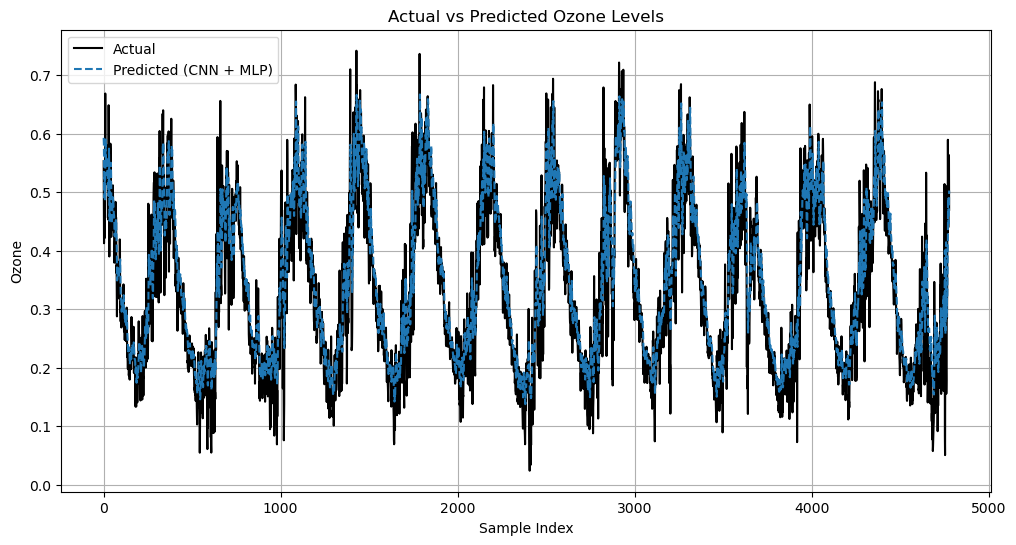

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# Convert numpy arrays to torch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1).to(device)

input_dim = X_train.shape[1]  # Number of features

# ----------- Models -----------

# 1. Simple MLP
class SimpleMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

# 2. Deeper MLP
class DeepMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

# 3. MLP with Dropout
class MLPDropout(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

# 4. MLP with BatchNorm
class MLPBatchNorm(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

# 5. 1D CNN (for time series with multiple features)
class CNN1D(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.fc = nn.Linear(32 * input_dim, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x shape: (batch_size, features)
        x = x.unsqueeze(1)  # shape (batch_size, 1, features)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# 6. CNN + MLP Hybrid
class CNN_MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv1d(16, 32, 3, padding=1),
            nn.ReLU()
        )
        self.mlp = nn.Sequential(
            nn.Linear(32 * input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.mlp(x)

# 7. LSTM Regressor
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # input expected: (batch, seq_len, features)
        x = x.unsqueeze(1)  # Add seq_len dimension = 1, shape (batch, 1, features)
        _, (hn, _) = self.lstm(x)
        out = self.fc(hn[-1])
        return out

# 8. GRU Regressor
class GRURegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = x.unsqueeze(1)  # shape (batch, seq_len=1, features)
        _, hn = self.gru(x)
        out = self.fc(hn[-1])
        return out

# ----------- Training function -----------
def train_model(model, X, y, epochs=100, lr=0.001):
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
    return model

# ----------- Evaluate model -----------
def evaluate_model(model, X, y_true):
    model.eval()
    with torch.no_grad():
        preds = model(X).cpu().numpy()
        y_true = y_true.cpu().numpy()
        mse = mean_squared_error(y_true, preds)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, preds)
        r2 = r2_score(y_true, preds)
    return preds, mse, rmse, mae, r2

# ----------- Run models -----------
models = {
    'Simple MLP': SimpleMLP(input_dim),
    'Deep MLP': DeepMLP(input_dim),
    'MLP with Dropout': MLPDropout(input_dim),
    'MLP with BatchNorm': MLPBatchNorm(input_dim),
    '1D CNN': CNN1D(input_dim),
    'CNN + MLP': CNN_MLP(input_dim),
    'LSTM': LSTMRegressor(input_dim),
    'GRU': GRURegressor(input_dim),
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    train_model(model, X_train_t, y_train_t, epochs=150, lr=0.001)
    preds, mse, rmse, mae, r2 = evaluate_model(model, X_test_t, y_test_t)
    results[name] = {'model': model, 'preds': preds, 'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}
    print(f"{name} - RMSE: {rmse:.4f}, R2: {r2*100:.2f} %")

# ----------- Plot best model results -----------
best_model_name = max(results, key=lambda k: results[k]['r2'])
print(f"\nBest model: {best_model_name} with R2 = {results[best_model_name]['r2']*100:.2f} %")

plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual', color='black')
plt.plot(results[best_model_name]['preds'], label=f'Predicted ({best_model_name})', linestyle='--')
plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Sample Index')
plt.ylabel('Ozone')
plt.legend()
plt.grid(True)
plt.show()


**Hyper Parameter Tuning**

**Optuna**

In [10]:
import optuna
from optuna.samplers import TPESampler, NSGAIISampler, RandomSampler
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Assume X_train_t, y_train_t, X_test_t, y_test_t, X_train, y_train are already defined
X_tr, X_val, y_tr, y_val = train_test_split(X_train_t, y_train_t, test_size=0.2, shuffle=False)

input_dim = X_train_t.shape[1]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- Model Factory for Optuna ---------- #
def create_model(trial, input_dim, model_type):
    if model_type == 'SimpleMLP':
        hidden = trial.suggest_int("hidden", 32, 128)
        return nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    elif model_type == 'DeepMLP':
        h1 = trial.suggest_int("h1", 64, 256)
        h2 = trial.suggest_int("h2", 32, 128)
        return nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Linear(h2, 1)
        )

    elif model_type == 'MLPDropout':
        h1 = trial.suggest_int("h1", 64, 256)
        h2 = trial.suggest_int("h2", 32, 128)
        dropout = trial.suggest_float("dropout", 0.1, 0.5)
        return nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h2, 1)
        )

    elif model_type == 'CNN1D':
        out_channels = trial.suggest_int("out_channels", 16, 64)
        kernel_size = trial.suggest_int("kernel_size", 2, 5)
        class CNN1D(nn.Module):
            def __init__(self):
                super().__init__()
                self.conv = nn.Sequential(
                    nn.Conv1d(1, out_channels, kernel_size=kernel_size, padding=1),
                    nn.ReLU(),
                    nn.Conv1d(out_channels, out_channels, kernel_size=kernel_size, padding=1),
                    nn.ReLU()
                )
                self.gap = nn.AdaptiveAvgPool1d(1)
                self.fc = nn.Linear(out_channels, 1)

            def forward(self, x):
                x = x.unsqueeze(1)
                x = self.conv(x)
                x = self.gap(x).squeeze(-1)
                return self.fc(x)
        return CNN1D()

    elif model_type == 'LSTM':
        hidden = trial.suggest_int("hidden_dim", 32, 128)
        layers = trial.suggest_int("num_layers", 1, 3)
        class LSTMRegressor(nn.Module):
            def __init__(self):
                super().__init__()
                self.lstm = nn.LSTM(input_dim, hidden, layers, batch_first=True)
                self.fc = nn.Linear(hidden, 1)

            def forward(self, x):
                x = x.unsqueeze(1)
                _, (hn, _) = self.lstm(x)
                return self.fc(hn[-1])
        return LSTMRegressor()

    elif model_type == 'GRU':
        hidden = trial.suggest_int("hidden_dim", 32, 128)
        layers = trial.suggest_int("num_layers", 1, 3)
        class GRURegressor(nn.Module):
            def __init__(self):
                super().__init__()
                self.gru = nn.GRU(input_dim, hidden, layers, batch_first=True)
                self.fc = nn.Linear(hidden, 1)

            def forward(self, x):
                x = x.unsqueeze(1)
                _, hn = self.gru(x)
                return self.fc(hn[-1])
        return GRURegressor()

    else:
        raise ValueError(f"Unknown model type: {model_type}")

# ---------- Training and Evaluation ---------- #
def train_model(model, X_train, y_train, epochs=300, lr=1e-3):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    for epoch in range(epochs):
        optimizer.zero_grad()
        out = model(X_train)
        loss = criterion(out, y_train)
        loss.backward()
        optimizer.step()

def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        preds = model(X_test).cpu().numpy()
        true = y_test.cpu().numpy()
        mse = mean_squared_error(true, preds)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(true, preds)
        r2 = r2_score(true, preds)
    return preds, mse, rmse, mae, r2

# ---------- Objective Function ---------- #
def objective(trial):
    model_type = trial.suggest_categorical("model_type", ["SimpleMLP", "DeepMLP", "MLPDropout", "CNN1D", "LSTM", "GRU"])
    model = create_model(trial, input_dim=X_tr.shape[1], model_type=model_type).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True))
    model.train()
    for epoch in range(100):
        optimizer.zero_grad()
        out = model(X_tr)
        loss = criterion(out, y_tr)
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        preds = model(X_val).cpu().numpy()
        true = y_val.cpu().numpy()
        r2 = r2_score(true, preds)
    return r2

# ---------- Run Multiple Studies with Different Samplers ---------- #
samplers = {
    "TPE": TPESampler(seed=42),
    "NSGAII": NSGAIISampler(seed=42),
    "Random": RandomSampler(seed=42),
}

best_trials = {}
for name, sampler in samplers.items():
    print(f"Running {name} search...")
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=50)
    best_trials[name] = study.best_trial
    print(f"Best {name} Trial:\n{study.best_trial}\n")

# ---------- Evaluate All Best Models on Test Set ---------- #
all_results = {}
for name, trial in best_trials.items():
    model_type = trial.params['model_type']
    model = create_model(trial, input_dim, model_type).to(device)
    train_model(model, X_train_t, y_train_t, epochs=300, lr=trial.params['lr'])
    preds, mse, rmse, mae, r2 = evaluate_model(model, X_test_t, y_test_t)
    all_results[name] = {
        "model_type": model_type,
        "r2": r2,
        "rmse": rmse,
        "mae": mae,
        "mse": mse,
    }

# ---------- Print Evaluation Results ---------- #
print("\n--- Evaluation of Best Models from Each Search ---")
for name, result in all_results.items():
    print(f"{name} Search:")
    print(f"  Model      : {result['model_type']}")
    print(f"  R²         : {result['r2']:.4f}")
    print(f"  RMSE       : {result['rmse']:.4f}")
    print(f"  MAE        : {result['mae']:.4f}")
    print(f"  MSE        : {result['mse']:.4f}\n")


/home/t2420363/miniconda3/envs/rapids-23.12/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-06-08 22:46:32,668] A new study created in memory with name: no-name-0b474456-58ff-4112-9092-a0ecb896494f


Running TPE search...


[I 2025-06-08 22:46:32,928] Trial 0 finished with value: 0.806015133857727 and parameters: {'model_type': 'DeepMLP', 'h1': 75, 'h2': 116, 'lr': 0.0015930522616241021}. Best is trial 0 with value: 0.806015133857727.
[I 2025-06-08 22:46:33,002] Trial 1 finished with value: 0.7841798067092896 and parameters: {'model_type': 'MLPDropout', 'h1': 99, 'h2': 61, 'dropout': 0.3099025726528951, 'lr': 0.0007309539835912913}. Best is trial 0 with value: 0.806015133857727.
[I 2025-06-08 22:46:33,067] Trial 2 finished with value: 0.8046981692314148 and parameters: {'model_type': 'DeepMLP', 'h1': 215, 'h2': 51, 'lr': 0.0010677482709481358}. Best is trial 0 with value: 0.806015133857727.
[I 2025-06-08 22:46:34,044] Trial 3 finished with value: 0.7639826536178589 and parameters: {'model_type': 'GRU', 'hidden_dim': 125, 'num_layers': 3, 'lr': 0.0004066563313514797}. Best is trial 0 with value: 0.806015133857727.
[I 2025-06-08 22:46:34,115] Trial 4 finished with value: 0.8110648393630981 and parameters: {

Best TPE Trial:
FrozenTrial(number=24, state=TrialState.COMPLETE, values=[0.8363633751869202], datetime_start=datetime.datetime(2025, 6, 8, 22, 46, 45, 542129), datetime_complete=datetime.datetime(2025, 6, 8, 22, 46, 45, 613570), params={'model_type': 'DeepMLP', 'h1': 184, 'h2': 101, 'lr': 0.003967071083520481}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'model_type': CategoricalDistribution(choices=('SimpleMLP', 'DeepMLP', 'MLPDropout', 'CNN1D', 'LSTM', 'GRU')), 'h1': IntDistribution(high=256, log=False, low=64, step=1), 'h2': IntDistribution(high=128, log=False, low=32, step=1), 'lr': FloatDistribution(high=0.01, log=True, low=0.0001, step=None)}, trial_id=24, value=None)

Running NSGAII search...


[I 2025-06-08 22:46:51,936] Trial 2 finished with value: 0.8071439862251282 and parameters: {'model_type': 'DeepMLP', 'h1': 215, 'h2': 51, 'lr': 0.0010677482709481358}. Best is trial 2 with value: 0.8071439862251282.
[I 2025-06-08 22:46:52,905] Trial 3 finished with value: 0.7795263528823853 and parameters: {'model_type': 'GRU', 'hidden_dim': 125, 'num_layers': 3, 'lr': 0.0004066563313514797}. Best is trial 2 with value: 0.8071439862251282.
[I 2025-06-08 22:46:52,971] Trial 4 finished with value: 0.8075569868087769 and parameters: {'model_type': 'DeepMLP', 'h1': 239, 'h2': 57, 'lr': 0.0021137059440645744}. Best is trial 4 with value: 0.8075569868087769.
[I 2025-06-08 22:46:54,421] Trial 5 finished with value: 0.7766788005828857 and parameters: {'model_type': 'LSTM', 'hidden_dim': 123, 'num_layers': 3, 'lr': 0.0015696396388661157}. Best is trial 4 with value: 0.8075569868087769.
[I 2025-06-08 22:46:54,479] Trial 6 finished with value: 0.8132948279380798 and parameters: {'model_type': 'S

Best NSGAII Trial:
FrozenTrial(number=48, state=TrialState.COMPLETE, values=[0.8357316255569458], datetime_start=datetime.datetime(2025, 6, 8, 22, 47, 15, 535002), datetime_complete=datetime.datetime(2025, 6, 8, 22, 47, 16, 10624), params={'model_type': 'LSTM', 'hidden_dim': 67, 'num_layers': 3, 'lr': 0.007843269804336332}, user_attrs={}, system_attrs={'NSGAIISampler:generation': 0}, intermediate_values={}, distributions={'model_type': CategoricalDistribution(choices=('SimpleMLP', 'DeepMLP', 'MLPDropout', 'CNN1D', 'LSTM', 'GRU')), 'hidden_dim': IntDistribution(high=128, log=False, low=32, step=1), 'num_layers': IntDistribution(high=3, log=False, low=1, step=1), 'lr': FloatDistribution(high=0.01, log=True, low=0.0001, step=None)}, trial_id=48, value=None)

Running Random search...


[I 2025-06-08 22:47:16,297] Trial 2 finished with value: 0.8130311965942383 and parameters: {'model_type': 'DeepMLP', 'h1': 215, 'h2': 51, 'lr': 0.0010677482709481358}. Best is trial 0 with value: 0.8139057159423828.
[I 2025-06-08 22:47:19,929] Trial 3 finished with value: 0.7842835783958435 and parameters: {'model_type': 'GRU', 'hidden_dim': 125, 'num_layers': 3, 'lr': 0.0004066563313514797}. Best is trial 0 with value: 0.8139057159423828.
[I 2025-06-08 22:47:19,994] Trial 4 finished with value: 0.7990831732749939 and parameters: {'model_type': 'DeepMLP', 'h1': 239, 'h2': 57, 'lr': 0.0021137059440645744}. Best is trial 0 with value: 0.8139057159423828.
[I 2025-06-08 22:47:21,591] Trial 5 finished with value: 0.7736696004867554 and parameters: {'model_type': 'LSTM', 'hidden_dim': 123, 'num_layers': 3, 'lr': 0.0015696396388661157}. Best is trial 0 with value: 0.8139057159423828.
[I 2025-06-08 22:47:21,654] Trial 6 finished with value: 0.7894330024719238 and parameters: {'model_type': 'S

Best Random Trial:
FrozenTrial(number=48, state=TrialState.COMPLETE, values=[0.8254153728485107], datetime_start=datetime.datetime(2025, 6, 8, 22, 47, 42, 947705), datetime_complete=datetime.datetime(2025, 6, 8, 22, 47, 43, 419783), params={'model_type': 'LSTM', 'hidden_dim': 67, 'num_layers': 3, 'lr': 0.007843269804336332}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'model_type': CategoricalDistribution(choices=('SimpleMLP', 'DeepMLP', 'MLPDropout', 'CNN1D', 'LSTM', 'GRU')), 'hidden_dim': IntDistribution(high=128, log=False, low=32, step=1), 'num_layers': IntDistribution(high=3, log=False, low=1, step=1), 'lr': FloatDistribution(high=0.01, log=True, low=0.0001, step=None)}, trial_id=48, value=None)


--- Evaluation of Best Models from Each Search ---
TPE Search:
  Model      : DeepMLP
  R²         : 0.8658
  RMSE       : 0.0508
  MAE        : 0.0364
  MSE        : 0.0026

NSGAII Search:
  Model      : LSTM
  R²         : 0.8633
  RMSE       : 0.0512
  MAE  

**Several Tuning Samplers(Optuna)**

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import optuna
from optuna.samplers import TPESampler, NSGAIISampler, RandomSampler
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, ParameterGrid

# ---------- Assume tensors are predefined ---------- #
# X_train_t, y_train_t, X_test_t, y_test_t, X_train, y_train
X_tr, X_val, y_tr, y_val = train_test_split(X_train_t, y_train_t, test_size=0.2, shuffle=False)
input_dim = X_train_t.shape[1]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- Model Factory ---------- #
def create_model(trial=None, input_dim=10, model_type='SimpleMLP', param_override=None):
    p = param_override if param_override else {}

    def get(key, default):
        if p.get(key) is not None:
            return p.get(key)
        elif trial is not None:
            return trial.suggest_int(key, *default)
        else:
            # Use the first value in the default tuple as the default
            return default[0]

    if model_type == 'SimpleMLP':
        hidden = get("hidden", (32, 128))
        return nn.Sequential(nn.Linear(input_dim, hidden), nn.ReLU(), nn.Linear(hidden, 1))

    elif model_type == 'DeepMLP':
        h1 = get("h1", (64, 256))
        h2 = get("h2", (32, 128))
        return nn.Sequential(nn.Linear(input_dim, h1), nn.ReLU(), nn.Linear(h1, h2), nn.ReLU(), nn.Linear(h2, 1))

    elif model_type == 'MLPDropout':
        h1 = get("h1", (64, 256))
        h2 = get("h2", (32, 128))
        dropout = p.get("dropout") if p.get("dropout") else trial.suggest_float("dropout", 0.1, 0.5)
        return nn.Sequential(
            nn.Linear(input_dim, h1), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(h1, h2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(h2, 1)
        )

    elif model_type == 'CNN1D':
        out_channels = get("out_channels", (16, 64))
        kernel_size = get("kernel_size", (2, 5))
        class CNN1D(nn.Module):
            def __init__(self):
                super().__init__()
                self.conv = nn.Sequential(
                    nn.Conv1d(1, out_channels, kernel_size=kernel_size, padding=1),
                    nn.ReLU(),
                    nn.Conv1d(out_channels, out_channels, kernel_size=kernel_size, padding=1),
                    nn.ReLU()
                )
                self.gap = nn.AdaptiveAvgPool1d(1)
                self.fc = nn.Linear(out_channels, 1)

            def forward(self, x):
                x = x.unsqueeze(1)
                x = self.conv(x)
                x = self.gap(x).squeeze(-1)
                return self.fc(x)
        return CNN1D()

    elif model_type == 'LSTM':
        hidden = get("hidden_dim", (32, 128))
        layers = get("num_layers", (1, 3))
        class LSTMRegressor(nn.Module):
            def __init__(self):
                super().__init__()
                self.lstm = nn.LSTM(input_dim, hidden, layers, batch_first=True)
                self.fc = nn.Linear(hidden, 1)

            def forward(self, x):
                x = x.unsqueeze(1)
                _, (hn, _) = self.lstm(x)
                return self.fc(hn[-1])
        return LSTMRegressor()

    elif model_type == 'GRU':
        hidden = get("hidden_dim", (32, 128))
        layers = get("num_layers", (1, 3))
        class GRURegressor(nn.Module):
            def __init__(self):
                super().__init__()
                self.gru = nn.GRU(input_dim, hidden, layers, batch_first=True)
                self.fc = nn.Linear(hidden, 1)

            def forward(self, x):
                x = x.unsqueeze(1)
                _, hn = self.gru(x)
                return self.fc(hn[-1])
        return GRURegressor()

    else:
        raise ValueError("Unknown model")

# ---------- Training ---------- #
def train_model(model, X, y, epochs=300, lr=1e-3):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    for _ in range(epochs):
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()

# ---------- Evaluation ---------- #
def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        pred = model(X).cpu().numpy()
        true = y.cpu().numpy()
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(true, pred)
    r2 = r2_score(true, pred)
    return pred, mse, rmse, mae, r2

# ---------- Optuna Objective ---------- #
def objective(trial):
    model_type = trial.suggest_categorical("model_type", ["SimpleMLP", "DeepMLP", "MLPDropout", "CNN1D", "LSTM", "GRU"])
    model = create_model(trial, input_dim, model_type).to(device)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    train_model(model, X_tr, y_tr, epochs=100, lr=lr)
    _, _, _, _, r2 = evaluate_model(model, X_val, y_val)
    return r2

# ---------- Run All Optuna Samplers ---------- #
samplers = {
    "TPE": TPESampler(seed=42),
    "NSGAII": NSGAIISampler(seed=42),
    "Random": RandomSampler(seed=42)
}
best_trials = {}
for name, sampler in samplers.items():
    print(f"Running {name} tuning...")
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=50)
    best_trials[name] = study.best_trial

# ---------- Manual Grid Search ---------- #
grid_results = []
grid = list(ParameterGrid({
    "model_type": ["SimpleMLP", "DeepMLP"],
    "lr": [0.001, 0.005],
    "hidden": [64, 128],
}))
for params in grid:
    model = create_model(None, input_dim, params['model_type'], param_override=params).to(device)
    train_model(model, X_tr, y_tr, epochs=100, lr=params['lr'])
    _, _, _, _, r2 = evaluate_model(model, X_val, y_val)
    params['r2'] = r2
    grid_results.append(params)

best_grid = max(grid_results, key=lambda x: x['r2'])

# ---------- Evaluate All Best Models ---------- #
print("\n--- Final Evaluation on Test Set ---")
all_results = {}
for name, trial in best_trials.items():
    model = create_model(trial, input_dim, trial.params['model_type']).to(device)
    train_model(model, X_train_t, y_train_t, epochs=300, lr=trial.params['lr'])
    _, mse, rmse, mae, r2 = evaluate_model(model, X_test_t, y_test_t)
    all_results[name] = {"model": trial.params['model_type'], "r2": r2, "rmse": rmse, "mae": mae, "mse": mse}

# Grid search result
grid_model = create_model(None, input_dim, best_grid['model_type'], param_override=best_grid).to(device)
train_model(grid_model, X_train_t, y_train_t, epochs=300, lr=best_grid['lr'])
_, mse, rmse, mae, r2 = evaluate_model(grid_model, X_test_t, y_test_t)
all_results['GridSearch'] = {"model": best_grid['model_type'], "r2": r2, "rmse": rmse, "mae": mae, "mse": mse}

for name, res in all_results.items():
    print(f"{name} Results:")
    print(f"  Model: {res['model']}\n  R2: {res['r2']:.4f}  RMSE: {res['rmse']:.4f}  MAE: {res['mae']:.4f}  MSE: {res['mse']:.4f}\n")


[I 2025-06-08 22:47:47,340] A new study created in memory with name: no-name-661ed196-94f9-46cf-a46d-8703ec739fe8
[I 2025-06-08 22:47:47,411] Trial 0 finished with value: 0.8058671355247498 and parameters: {'model_type': 'DeepMLP', 'h1': 75, 'h2': 116, 'lr': 0.0015930522616241021}. Best is trial 0 with value: 0.8058671355247498.
[I 2025-06-08 22:47:47,486] Trial 1 finished with value: 0.7850289940834045 and parameters: {'model_type': 'MLPDropout', 'h1': 99, 'h2': 61, 'dropout': 0.3099025726528951, 'lr': 0.0007309539835912913}. Best is trial 0 with value: 0.8058671355247498.


Running TPE tuning...


[I 2025-06-08 22:47:47,555] Trial 2 finished with value: 0.7933903932571411 and parameters: {'model_type': 'DeepMLP', 'h1': 215, 'h2': 51, 'lr': 0.0010677482709481358}. Best is trial 0 with value: 0.8058671355247498.
[I 2025-06-08 22:47:48,532] Trial 3 finished with value: 0.7825679779052734 and parameters: {'model_type': 'GRU', 'hidden_dim': 125, 'num_layers': 3, 'lr': 0.0004066563313514797}. Best is trial 0 with value: 0.8058671355247498.
[I 2025-06-08 22:47:48,614] Trial 4 finished with value: 0.8140289783477783 and parameters: {'model_type': 'DeepMLP', 'h1': 239, 'h2': 57, 'lr': 0.0021137059440645744}. Best is trial 4 with value: 0.8140289783477783.
[I 2025-06-08 22:47:50,120] Trial 5 finished with value: 0.7744691371917725 and parameters: {'model_type': 'LSTM', 'hidden_dim': 123, 'num_layers': 3, 'lr': 0.0015696396388661157}. Best is trial 4 with value: 0.8140289783477783.
[I 2025-06-08 22:47:50,195] Trial 6 finished with value: 0.7934184670448303 and parameters: {'model_type': 'S

Running NSGAII tuning...


[I 2025-06-08 22:48:06,305] Trial 2 finished with value: 0.8186807632446289 and parameters: {'model_type': 'DeepMLP', 'h1': 215, 'h2': 51, 'lr': 0.0010677482709481358}. Best is trial 2 with value: 0.8186807632446289.
[I 2025-06-08 22:48:07,287] Trial 3 finished with value: 0.7638920545578003 and parameters: {'model_type': 'GRU', 'hidden_dim': 125, 'num_layers': 3, 'lr': 0.0004066563313514797}. Best is trial 2 with value: 0.8186807632446289.
[I 2025-06-08 22:48:07,358] Trial 4 finished with value: 0.8094182014465332 and parameters: {'model_type': 'DeepMLP', 'h1': 239, 'h2': 57, 'lr': 0.0021137059440645744}. Best is trial 2 with value: 0.8186807632446289.
[I 2025-06-08 22:48:08,821] Trial 5 finished with value: 0.7815045118331909 and parameters: {'model_type': 'LSTM', 'hidden_dim': 123, 'num_layers': 3, 'lr': 0.0015696396388661157}. Best is trial 2 with value: 0.8186807632446289.
[I 2025-06-08 22:48:08,882] Trial 6 finished with value: 0.8131816983222961 and parameters: {'model_type': 'S

Running Random tuning...


[I 2025-06-08 22:48:33,375] Trial 2 finished with value: 0.8175048828125 and parameters: {'model_type': 'DeepMLP', 'h1': 215, 'h2': 51, 'lr': 0.0010677482709481358}. Best is trial 2 with value: 0.8175048828125.
[I 2025-06-08 22:48:34,422] Trial 3 finished with value: 0.7673729658126831 and parameters: {'model_type': 'GRU', 'hidden_dim': 125, 'num_layers': 3, 'lr': 0.0004066563313514797}. Best is trial 2 with value: 0.8175048828125.
[I 2025-06-08 22:48:34,497] Trial 4 finished with value: 0.8134018182754517 and parameters: {'model_type': 'DeepMLP', 'h1': 239, 'h2': 57, 'lr': 0.0021137059440645744}. Best is trial 2 with value: 0.8175048828125.
[I 2025-06-08 22:48:36,056] Trial 5 finished with value: 0.7828101515769958 and parameters: {'model_type': 'LSTM', 'hidden_dim': 123, 'num_layers': 3, 'lr': 0.0015696396388661157}. Best is trial 2 with value: 0.8175048828125.
[I 2025-06-08 22:48:36,118] Trial 6 finished with value: 0.8007956743240356 and parameters: {'model_type': 'SimpleMLP', 'hid


--- Final Evaluation on Test Set ---
TPE Results:
  Model: DeepMLP
  R2: 0.8539  RMSE: 0.0530  MAE: 0.0384  MSE: 0.0028

NSGAII Results:
  Model: LSTM
  R2: 0.8639  RMSE: 0.0511  MAE: 0.0368  MSE: 0.0026

Random Results:
  Model: LSTM
  R2: 0.8635  RMSE: 0.0512  MAE: 0.0369  MSE: 0.0026

GridSearch Results:
  Model: SimpleMLP
  R2: 0.8221  RMSE: 0.0585  MAE: 0.0426  MSE: 0.0034



In [12]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, r2_score
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# ---- TorchRegressor ----
class TorchRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, model_type='SimpleMLP', input_dim=10, hidden=64, h1=128, h2=64,
                 dropout=0.2, lr=1e-3, epochs=100, batch_size=32,
                 out_channels=32, kernel_size=3, num_layers=1, hidden_dim=64,
                 device='cpu', sequence_length=1):
        self.model_type = model_type
        self.input_dim = input_dim
        self.hidden = hidden
        self.h1 = h1
        self.h2 = h2
        self.dropout = dropout
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.device = device
        self.sequence_length = sequence_length

    def _create_model(self):
        if self.model_type == 'SimpleMLP':
            return nn.Sequential(
                nn.Linear(self.input_dim, self.hidden),
                nn.ReLU(),
                nn.Linear(self.hidden, 1)
            )
        elif self.model_type == 'DeepMLP':
            return nn.Sequential(
                nn.Linear(self.input_dim, self.h1),
                nn.ReLU(),
                nn.Linear(self.h1, self.h2),
                nn.ReLU(),
                nn.Linear(self.h2, 1)
            )
        elif self.model_type == 'MLPDropout':
            return nn.Sequential(
                nn.Linear(self.input_dim, self.h1),
                nn.ReLU(),
                nn.Dropout(self.dropout),
                nn.Linear(self.h1, self.h2),
                nn.ReLU(),
                nn.Dropout(self.dropout),
                nn.Linear(self.h2, 1)
            )
        elif self.model_type == 'CNN1D':
            class CNN1D(nn.Module):
                def __init__(self, in_dim, out_ch, k):
                    super().__init__()
                    self.conv = nn.Sequential(
                        nn.Conv1d(1, out_ch, kernel_size=k, padding=1),
                        nn.ReLU(),
                        nn.Conv1d(out_ch, out_ch, kernel_size=k, padding=1),
                        nn.ReLU()
                    )
                    self.gap = nn.AdaptiveAvgPool1d(1)
                    self.fc = nn.Linear(out_ch, 1)

                def forward(self, x):
                    x = x.unsqueeze(1)  # [B, 1, input_dim]
                    x = self.conv(x)
                    x = self.gap(x).squeeze(-1)
                    return self.fc(x)

            return CNN1D(self.input_dim, self.out_channels, self.kernel_size)

        elif self.model_type == 'LSTM':
            class LSTMModel(nn.Module):
                def __init__(self, in_dim, hidden, layers):
                    super().__init__()
                    self.lstm = nn.LSTM(in_dim, hidden, layers, batch_first=True)
                    self.fc = nn.Linear(hidden, 1)

                def forward(self, x):
                    _, (hn, _) = self.lstm(x)
                    return self.fc(hn[-1])

            return LSTMModel(self.input_dim, self.hidden_dim, self.num_layers)

        elif self.model_type == 'GRU':
            class GRUModel(nn.Module):
                def __init__(self, in_dim, hidden, layers):
                    super().__init__()
                    self.gru = nn.GRU(in_dim, hidden, layers, batch_first=True)
                    self.fc = nn.Linear(hidden, 1)

                def forward(self, x):
                    _, hn = self.gru(x)
                    return self.fc(hn[-1])

            return GRUModel(self.input_dim, self.hidden_dim, self.num_layers)

        else:
            raise ValueError(f"Unknown model type: {self.model_type}")

    def _reshape_input(self, X):
        # Convert DataFrame to numpy array if needed
        if hasattr(X, "values"):
            X_np = X.values
        else:
            X_np = X
        X_t = torch.tensor(X_np, dtype=torch.float32).to(self.device)
        if self.model_type == 'CNN1D':
            return X_t  # CNN will add channel dim later
        elif self.model_type in ['LSTM', 'GRU']:
            return X_t.view(X_np.shape[0], 1, self.input_dim)  # [B, seq_len=1, input_dim]
        else:
            return X_t

    def fit(self, X, y):
        X_t = self._reshape_input(X)
        # Convert y to numpy array if it's a pandas Series
        if hasattr(y, "values"):
            y_np = y.values
        else:
            y_np = y
        y_t = torch.tensor(y_np, dtype=torch.float32).view(-1, 1).to(self.device)

        self.model_ = self._create_model().to(self.device)
        optimizer = optim.Adam(self.model_.parameters(), lr=self.lr)
        criterion = nn.MSELoss()

        self.model_.train()
        for _ in range(self.epochs):
            optimizer.zero_grad()
            output = self.model_(X_t)
            loss = criterion(output, y_t)
            loss.backward()
            optimizer.step()
        return self

    def predict(self, X):
        self.model_.eval()
        X_t = self._reshape_input(X)
        with torch.no_grad():
            preds = self.model_(X_t).cpu().numpy().flatten()
        return preds

# ---- Example Usage ----
if __name__ == "__main__":
 

    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    param_grid = {
        'model_type': ['LSTM', 'GRU', 'CNN1D', 'SimpleMLP', 'DeepMLP', 'MLPDropout'],
        'hidden': [64, 128],
        'h1': [64, 128],
        'h2': [32, 64],
        'dropout': [0.1, 0.2],
        'out_channels': [16, 32],
        'kernel_size': [2, 3, 5],
        'num_layers': [1, 2],
        'lr': [1e-3],
        'batch_size': [32],
        'epochs': [100],
        'input_dim': [X_train.shape[1]],
        'hidden_dim': [64],
        'num_layers': [1],
        'out_channels': [32],
        'kernel_size': [3],
        'device': [device]
    }

    reg = TorchRegressor()
    grid_search = GridSearchCV(reg, param_grid, scoring=make_scorer(r2_score), cv=5, verbose=2)
    
    # Fit the grid search on the training data
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    print("Best Model:", best_model.model_type)
    print("Best Score:", grid_search.best_score_)
    print("Best Params:", grid_search.best_params_)
    print("Test R2 Score:", r2_score(y_test, y_pred))


Fitting 5 folds for each of 96 candidates, totalling 480 fits
[CV] END batch_size=32, device=cuda, dropout=0.1, epochs=100, h1=64, h2=32, hidden=64, hidden_dim=64, input_dim=154, kernel_size=3, lr=0.001, model_type=LSTM, num_layers=1, out_channels=32; total time=   0.2s
[CV] END batch_size=32, device=cuda, dropout=0.1, epochs=100, h1=64, h2=32, hidden=64, hidden_dim=64, input_dim=154, kernel_size=3, lr=0.001, model_type=LSTM, num_layers=1, out_channels=32; total time=   0.2s
[CV] END batch_size=32, device=cuda, dropout=0.1, epochs=100, h1=64, h2=32, hidden=64, hidden_dim=64, input_dim=154, kernel_size=3, lr=0.001, model_type=LSTM, num_layers=1, out_channels=32; total time=   0.2s
[CV] END batch_size=32, device=cuda, dropout=0.1, epochs=100, h1=64, h2=32, hidden=64, hidden_dim=64, input_dim=154, kernel_size=3, lr=0.001, model_type=LSTM, num_layers=1, out_channels=32; total time=   0.2s
[CV] END batch_size=32, device=cuda, dropout=0.1, epochs=100, h1=64, h2=32, hidden=64, hidden_dim=64, 

***RAndomizedSearchCV**

In [13]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, r2_score
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# ---- TorchRegressor ----
class TorchRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, model_type='SimpleMLP', input_dim=10, hidden=64, h1=128, h2=64,
                 dropout=0.2, lr=1e-3, epochs=100, batch_size=32,
                 out_channels=32, kernel_size=3, num_layers=1, hidden_dim=64,
                 device='cpu', sequence_length=1):
        self.model_type = model_type
        self.input_dim = input_dim
        self.hidden = hidden
        self.h1 = h1
        self.h2 = h2
        self.dropout = dropout
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.device = device
        self.sequence_length = sequence_length

    def _create_model(self):
        if self.model_type == 'SimpleMLP':
            return nn.Sequential(
                nn.Linear(self.input_dim, self.hidden),
                nn.ReLU(),
                nn.Linear(self.hidden, 1)
            )
        elif self.model_type == 'DeepMLP':
            return nn.Sequential(
                nn.Linear(self.input_dim, self.h1),
                nn.ReLU(),
                nn.Linear(self.h1, self.h2),
                nn.ReLU(),
                nn.Linear(self.h2, 1)
            )
        elif self.model_type == 'MLPDropout':
            return nn.Sequential(
                nn.Linear(self.input_dim, self.h1),
                nn.ReLU(),
                nn.Dropout(self.dropout),
                nn.Linear(self.h1, self.h2),
                nn.ReLU(),
                nn.Dropout(self.dropout),
                nn.Linear(self.h2, 1)
            )
        elif self.model_type == 'CNN1D':
            class CNN1D(nn.Module):
                def __init__(self, in_dim, out_ch, k):
                    super().__init__()
                    self.conv = nn.Sequential(
                        nn.Conv1d(1, out_ch, kernel_size=k, padding=1),
                        nn.ReLU(),
                        nn.Conv1d(out_ch, out_ch, kernel_size=k, padding=1),
                        nn.ReLU()
                    )
                    self.gap = nn.AdaptiveAvgPool1d(1)
                    self.fc = nn.Linear(out_ch, 1)

                def forward(self, x):
                    x = x.unsqueeze(1)  # [B, 1, input_dim]
                    x = self.conv(x)
                    x = self.gap(x).squeeze(-1)
                    return self.fc(x)

            return CNN1D(self.input_dim, self.out_channels, self.kernel_size)

        elif self.model_type == 'LSTM':
            class LSTMModel(nn.Module):
                def __init__(self, in_dim, hidden, layers):
                    super().__init__()
                    self.lstm = nn.LSTM(in_dim, hidden, layers, batch_first=True)
                    self.fc = nn.Linear(hidden, 1)

                def forward(self, x):
                    _, (hn, _) = self.lstm(x)
                    return self.fc(hn[-1])

            return LSTMModel(self.input_dim, self.hidden_dim, self.num_layers)

        elif self.model_type == 'GRU':
            class GRUModel(nn.Module):
                def __init__(self, in_dim, hidden, layers):
                    super().__init__()
                    self.gru = nn.GRU(in_dim, hidden, layers, batch_first=True)
                    self.fc = nn.Linear(hidden, 1)

                def forward(self, x):
                    _, hn = self.gru(x)
                    return self.fc(hn[-1])

            return GRUModel(self.input_dim, self.hidden_dim, self.num_layers)

        else:
            raise ValueError(f"Unknown model type: {self.model_type}")

    def _reshape_input(self, X):
        if isinstance(X, np.ndarray):
            X_arr = X
        else:
            X_arr = X.values if hasattr(X, "values") else np.array(X)
        X_t = torch.tensor(X_arr, dtype=torch.float32).to(self.device)
        if self.model_type == 'CNN1D':
            return X_t  # CNN will add channel dim later
        elif self.model_type in ['LSTM', 'GRU']:
            return X_t.view(X_arr.shape[0], 1, self.input_dim)  # [B, seq_len=1, input_dim]
        else:
            return X_t

    def fit(self, X, y):
        X_t = self._reshape_input(X)
        y_arr = np.asarray(y)  # Ensure y is a numpy array
        y_t = torch.tensor(y_arr, dtype=torch.float32).view(-1, 1).to(self.device)

        self.model_ = self._create_model().to(self.device)
        optimizer = optim.Adam(self.model_.parameters(), lr=self.lr)
        criterion = nn.MSELoss()

        self.model_.train()
        for _ in range(self.epochs):
            optimizer.zero_grad()
            output = self.model_(X_t)
            loss = criterion(output, y_t)
            loss.backward()
            optimizer.step()
        return self

    def predict(self, X):
        self.model_.eval()
        X_t = self._reshape_input(X)
        with torch.no_grad():
            preds = self.model_(X_t).cpu().numpy().flatten()
        return preds

# ---- Example Usage ----
if __name__ == "__main__":
    # Generate synthetic regression dataset
    # X, y = make_regression(n_samples=500, n_features=20, noise=0.1, random_state=42)
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    param_dist = {
        'model_type': ['LSTM', 'GRU', 'CNN1D', 'SimpleMLP', 'DeepMLP', 'MLPDropout'],
        'h1': [64, 128, 256],
        'h2': [32, 64, 128],
        'dropout': [0.1, 0.2, 0.3],
        'lr': [1e-2, 1e-3, 1e-4],
        'epochs': [50, 100, 200],
        'input_dim': [X_train.shape[1]],
        'hidden_dim': [32, 64, 128],
        'num_layers': [1, 2, 3],
        'batch_size': [32, 64, 128],
        'out_channels': [16, 32, 64],
        'kernel_size': [3, 5, 7],
        'device': [device]
    }

    reg = TorchRegressor()
    random_search = RandomizedSearchCV(
        reg,
        param_distributions=param_dist,
        n_iter=10,
        scoring=make_scorer(r2_score),
        cv=3,
        verbose=2,
        random_state=42
    )
    random_search.fit(X_train, y_train)

    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_test)
    print("\nBest Parameters:", random_search.best_params_)
    print("Test R2 Score:", r2_score(y_test, y_pred))


Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END batch_size=64, device=cuda, dropout=0.1, epochs=50, h1=64, h2=128, hidden_dim=64, input_dim=154, kernel_size=7, lr=0.0001, model_type=CNN1D, num_layers=3, out_channels=64; total time=   1.5s
[CV] END batch_size=64, device=cuda, dropout=0.1, epochs=50, h1=64, h2=128, hidden_dim=64, input_dim=154, kernel_size=7, lr=0.0001, model_type=CNN1D, num_layers=3, out_channels=64; total time=   1.5s
[CV] END batch_size=64, device=cuda, dropout=0.1, epochs=50, h1=64, h2=128, hidden_dim=64, input_dim=154, kernel_size=7, lr=0.0001, model_type=CNN1D, num_layers=3, out_channels=64; total time=   1.5s
[CV] END batch_size=64, device=cuda, dropout=0.1, epochs=200, h1=64, h2=64, hidden_dim=128, input_dim=154, kernel_size=3, lr=0.001, model_type=DeepMLP, num_layers=2, out_channels=64; total time=   0.1s
[CV] END batch_size=64, device=cuda, dropout=0.1, epochs=200, h1=64, h2=64, hidden_dim=128, input_dim=154, kernel_size=3, lr=0.001, model